In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/btc-data/BTC.csv


In [14]:
#Import required libraries
import math
import time
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from keras.models import save_model
from keras.layers import SimpleRNN, LSTM, GRU, Bidirectional, Dense, Dropout
from keras.layers import MultiHeadAttention, LayerNormalization, Input, GlobalAveragePooling1D, Embedding, Add
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from keras.models import Sequential, Model
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, STATUS_FAIL, space_eval
import tensorflow as tf
from keras.models import load_model
import os
from tensorflow.keras import backend as K
from optuna.integration import TFKerasPruningCallback


# Importing the CSV file
df = pd.read_csv("/Applications/forvscode/BachelorFinal/Hybrid-models-for-TS-processing/docs/BTC.csv")

# Sorting the DataFrame by the date column
df = df.sort_values(by='Date')

df.isnull().sum()

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set the 'Date' column as the index
df.set_index('Date', inplace=True)


# Prepare the data
close_prices = df['Close'].astype(float)

# Length of training data
training_data_len = math.ceil(len(close_prices) * 0.80)

time_step = 30

# Split close into train/test (ONLY close, no HW yet)
train_close = close_prices.iloc[:training_data_len]
test_close  = close_prices.iloc[training_data_len:]

# Fit Holt-Winters ONLY on train
hw_model = ExponentialSmoothing(train_close, trend='mul', seasonal='mul', seasonal_periods=365)
hw_fit = hw_model.fit()

# Base line for train (in-sample) and test (forecast)
base_train = hw_fit.fittedvalues.reindex(train_close.index)
base_train = base_train.fillna(train_close)  # safety: avoid NaNs -> ratio=1 for those points

base_test = hw_fit.forecast(len(test_close))

# Ratio (residual) series: this is what NN will model
ratio_train = (train_close / base_train).to_numpy()
ratio_test  = (test_close  / base_test).to_numpy()

# Build test_values with overlap of last time_step from train (needed for windowing)
train_values = ratio_train
test_values  = np.concatenate([ratio_train[-time_step:], ratio_test])

# Normalize using only training data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_values.reshape(-1, 1))
scaled_test = scaler.transform(test_values.reshape(-1, 1))

# Build training sequences
x_train, y_train = [], []
for i in range(time_step, len(scaled_train)):
    x_train.append(scaled_train[i - time_step:i, 0])
    y_train.append(scaled_train[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Build test sequences
x_test = []
for i in range(time_step, len(scaled_test)):
    x_test.append(scaled_test[i - time_step:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# True y_test is the REAL close on test (as before)
y_test = test_close.to_numpy()


# Define the Mish activation function
def mish(x):
    return x * K.tanh(K.softplus(x))

# Define the objective function for Optuna
def objective(trial):
    # Hyperparameters to tune
    learning_rate = trial.suggest_float('learning_rate', 0.0001, 0.01, log=True)
    units = trial.suggest_int('units', 20, 50, step=5)
    dropout_rate = trial.suggest_float('dropout_rate', 0, 0.3)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    epochs = trial.suggest_int('epochs', 50, 150, step=10)
    num_blocks = trial.suggest_int('num_blocks', 1, 4)
    num_heads = trial.suggest_int('num_heads', 2, 10, step=2)
    head_size = trial.suggest_int('head_size', 8, 64, step=8)

    # Define the model architecture
    def create_helformer_model(input_shape):
        inputs = Input(shape=input_shape)
        x = inputs

        for _ in range(num_blocks):
            x_norm1 = LayerNormalization(epsilon=1e-6)(x)
            attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout_rate)(x_norm1, x_norm1)
            x = x + attention_output

            x_norm2 = LayerNormalization(epsilon=1e-6)(x)
            x = x + x_norm2

        # LSTM layer
        x = LSTM(units, activation=mish, return_sequences=False)(x)

        # Output layer
        outputs = Dense(1)(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

    # Create and compile the model
    input_shape = (x_train.shape[1], x_train.shape[2])
    model = create_helformer_model(input_shape)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')

    # Train the model
    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=0.2,
        verbose=0,
        callbacks=[TFKerasPruningCallback(trial, 'val_loss')]
    )

    # Predictions on validation data
    val_loss = min(history.history['val_loss'])
    return val_loss

# Run the Optuna optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
best_params = study.best_params
print("Best hyperparameters:", best_params)

/Applications/forvscode/BachelorFinal/Hybrid-models-for-TS-processing/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Applications/forvscode/BachelorFinal/Hybrid-models-for-TS-processing/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
[I 2025-12-22 21:41:22,769] A new study created in memory with name: no-name-0cb69c90-39da-424c-bbd8-bc60d0314162
[I 2025-12-22 21:42:12,084] Trial 0 finished with value: 0.0005712282145395875 and parameters: {'learning_rate': 0.00047452332106645605, 'units': 40, 'dropout_rate': 0.04877342809707317, 'batch_size': 16, 'epochs': 50, 'num_blocks': 4, 'num_heads': 2, 'head_size': 32}. Best is trial 0 with value: 0.0005712282145395875.
[I 2025-12-22 21:43:54,008] Trial 1 finished with value: 0.000

KeyboardInterrupt: 

In [ ]:
best_params = {'learning_rate': 0.008155950097119445,
 'units': 40,
 'dropout_rate': 0.1669279324208346,
 'batch_size': 16,
 'epochs': 100,
 'num_blocks': 1,
 'num_heads': 6,
 'head_size': 64}

In [15]:
# Retrain the model using the best hyperparameters
def create_best_helformer_model(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs

    for _ in range(best_params['num_blocks']):
        x_norm1 = LayerNormalization(epsilon=1e-6)(x)
        attention_output = MultiHeadAttention(num_heads=best_params['num_heads'], key_dim=best_params['head_size'], dropout=best_params['dropout_rate'])(x_norm1, x_norm1)
        x = x + attention_output

        x_norm2 = LayerNormalization(epsilon=1e-6)(x)
        x = x + x_norm2

    # LSTM layer
    x = LSTM(best_params['units'], activation=mish, return_sequences=False)(x)

    # Output layer
    outputs = Dense(1)(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create and compile the model with the best parameters
final_model_Helformer = create_best_helformer_model((x_train.shape[1], x_train.shape[2]))
final_model_Helformer.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='mean_squared_error')

# Train the model
print("Training final Helformer model")
final_history_Helformer = final_model_Helformer.fit(x_train, y_train, batch_size=best_params['batch_size'], epochs=best_params['epochs'], verbose=1)# Verbose set to 1 for detailed output during training

final_model_Helformer.save('Main_Helformer.h5')

Training final Helformer model
Epoch 1/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0050
Epoch 2/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.9951e-04
Epoch 3/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010    
Epoch 4/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.5323e-04
Epoch 5/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010    
Epoch 6/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.6430e-04
Epoch 7/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.5546e-04
Epoch 8/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010
Epoch 9/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010
Epoch 10/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.5512e-04
Epoch 11/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.8776e-04
Epoch 12/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.8793e-04
Epoch 13/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.8720e-04
Epoch 14/100
136/136 ━━━━━━━━━━━━━━━━━━━

In [11]:
RESULTS_DIR = "/kaggle/working/results" if os.path.exists("/kaggle/working") else "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Predicting test data
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Metrics saved to: Performance_metrics_2025-12-22_21-50-25.txt
Trading metrics saved to: Trading_metrics.txt


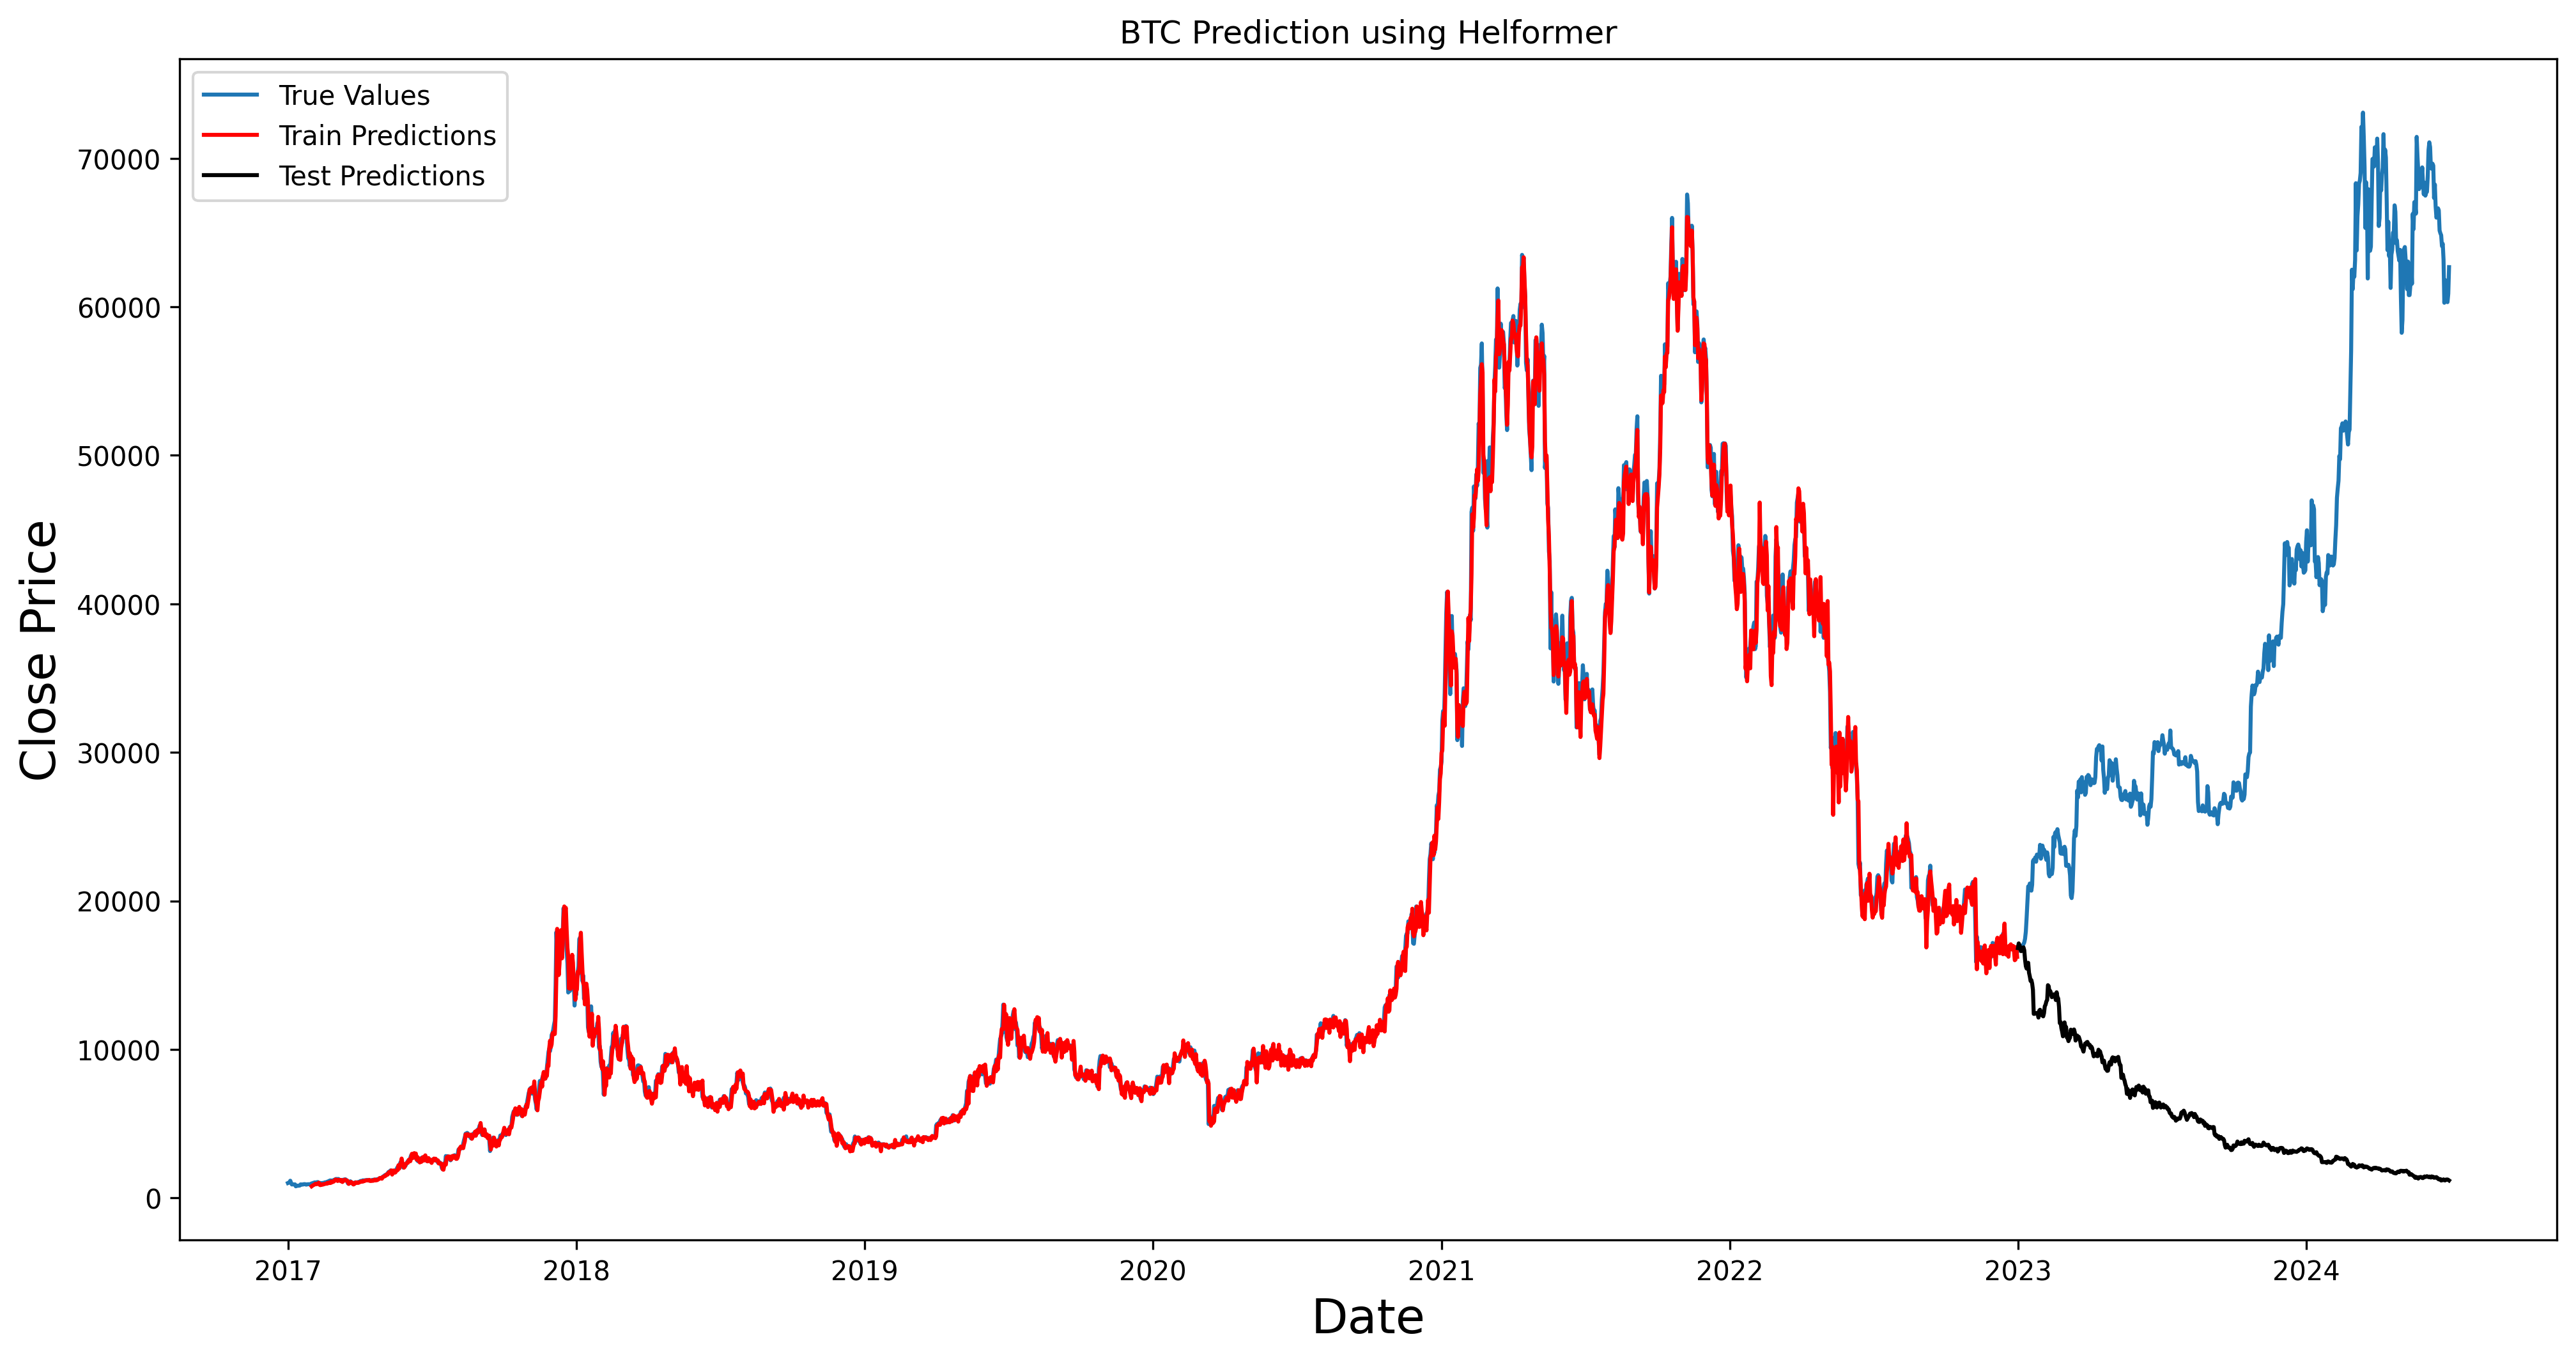

In [16]:
train_predictions = final_model_Helformer.predict(x_train)
train_predictions = scaler.inverse_transform(train_predictions).flatten()  # ratio_hat

# Convert ratio_hat -> close_hat using base_train
train_predictions = train_predictions * base_train.to_numpy()[time_step:training_data_len]

y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()  # ratio_true
y_train_rescaled = y_train_rescaled * base_train.to_numpy()[time_step:training_data_len]  # close_true

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Function to calculate KGE (Kling-Gupta Efficiency)
def kge(y_true, y_pred):
    cc = np.corrcoef(y_true, y_pred)[0, 1]  # Correlation coefficient
    alpha = np.std(y_pred) / np.std(y_true)  # Variability ratio
    beta = np.mean(y_pred) / np.mean(y_true)  # Bias ratio
    return 1 - np.sqrt((cc - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

# Predictions on testing data
print("Predicting test data")
test_predictions = final_model_Helformer.predict(x_test)
test_predictions = scaler.inverse_transform(test_predictions).flatten()  # ratio_hat

# Convert ratio_hat -> close_hat using base_test FORECAST (no leakage)
test_predictions = test_predictions * base_test.to_numpy()

# Calculate metrics for training data
train_mse = mean_squared_error(y_train_rescaled, train_predictions)
train_rmse = np.sqrt(train_mse)
train_mape = mean_absolute_percentage_error(y_train_rescaled, train_predictions)
train_mae = mean_absolute_error(y_train_rescaled, train_predictions)
train_r2 = r2_score(y_train_rescaled, train_predictions)
train_evs = explained_variance_score(y_train_rescaled, train_predictions)
train_kge = kge(y_train_rescaled, train_predictions)

# Calculate metrics for testing data
test_mse = mean_squared_error(y_test, test_predictions)
test_rmse = np.sqrt(test_mse)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)
test_evs = explained_variance_score(y_test, test_predictions)
test_kge = kge(y_test, test_predictions)

# Get current date and time
now = datetime.datetime.now()
timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
readable_time = now.strftime("%Y-%m-%d %H:%M:%S")

# Define file path and name
filename = f"Performance_metrics_{timestamp}.txt"
filepath = os.path.join("results/", filename)


# Write metrics to file
with open(filepath, 'w') as f:               # Change filename to filepath for codeocean
    f.write(f"::     ::\n")
    f.write(f"Training Data Evaluation Metrics\n")
    f.write(f"Timestamp: {readable_time}\n\n")
    f.write(f"MSE: {train_mse:.4f}\n")
    f.write(f"RMSE: {train_rmse:.4f}\n")
    f.write(f"MAPE: {train_mape:.4f}%\n")
    f.write(f"MAE: {train_mae:.4f}\n")
    f.write(f"R^2 Score: {train_r2:.4f}\n")
    f.write(f"Explained Variance Score (EVS): {train_evs:.4f}\n")
    f.write(f"KGE: {train_kge:.4f}\n")
    
    f.write(f"-----\n")
    f.write(f"Testing Data Evaluation Metrics\n")
    f.write(f"Timestamp: {readable_time}\n\n")
    f.write(f"MSE: {test_mse:.4f}\n")
    f.write(f"RMSE: {test_rmse:.4f}\n")
    f.write(f"MAPE: {test_mape:.4f}%\n")
    f.write(f"MAE: {test_mae:.4f}\n")
    f.write(f"R^2 Score: {test_r2:.4f}\n")
    f.write(f"Explained Variance Score (EVS): {test_evs:.4f}\n")
    f.write(f"KGE: {test_kge:.4f}\n")

print(f"Metrics saved to: {filename}")


# Plot the data
plt.figure(figsize=(16,8), dpi=300)
plt.title('BTC Prediction using Helformer')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)

# Plot original data
plt.plot(df['Close'], label='True Values')

# Create a list of NaNs to fill in the missing values in the plot
train_predictions_plot = [np.nan] * len(df)
train_predictions_plot[time_step:training_data_len] = train_predictions

# Add training predictions to the plot
plt.plot(df.index, train_predictions_plot, color='red', label='Train Predictions')

# Create a list of NaNs to fill in the missing values in the plot
test_predictions_plot = [np.nan] * len(df)
test_predictions_plot[training_data_len:] = test_predictions

# Add test predictions to the plot
plt.plot(df.index, test_predictions_plot, color='black', label='Test Predictions')

plt.legend()

plt.savefig ("results/Helformer_Predictions.png")


# Assuming observed_values = y_test and predicted_values = test_predictions
observed_values = y_test
predicted_values = test_predictions

# Initialize an array to store returns with transaction cost
returns_with_cost = []

for i in range(1, len(observed_values)):
    trade_signal = np.sign(predicted_values[i] - observed_values[i-1])

    Rt = np.log(observed_values[i] / observed_values[i-1]) * trade_signal

    # Apply transaction cost
    Rt_after_cost = Rt - 0.01 * abs(Rt)

    returns_with_cost.append(Rt_after_cost)

# Calculate net value (NV)
net_value = np.cumsum(returns_with_cost) + 1

# Calculate total returns
total_return = net_value[-1] - 1
total_return_pcnt = total_return * 100

# Calculate volatility (standard deviation of returns)
volatility = np.std(returns_with_cost)

# Calculate max drawdown
drawdowns = 1 - net_value / np.maximum.accumulate(net_value)
max_drawdown = np.max(drawdowns)
max_drawdown_inv = max_drawdown * -1

# Set annual risk-free rate (Rf) to 1%
risk_free_rate_annual = 0.01
risk_free_rate_daily = risk_free_rate_annual / 365  # Convert to daily risk-free rate

# Calculate Sharpe ratio
expected_return = np.mean(returns_with_cost)
sharpe_ratio = (expected_return - risk_free_rate_daily) / volatility * np.sqrt(365)

# Define file path and name
filename = f"Trading_metrics.txt"
filepath = os.path.join("results", filename)    #for code ocean

# Write metrics to file
with open(filepath, 'w') as f:                 
    f.write(f"::     ::\n")
    f.write(f"Trading Metrics\n")
    f.write(f"Timestamp: {readable_time}\n")
    f.write(f"Total Return: {total_return_pcnt:.4f}%\n")
    f.write(f"Volatility: {volatility:.4f}\n")
    f.write(f"Max Drawdown: {max_drawdown_inv:.4f}\n")
    f.write(f"Sharpe Ratio: {sharpe_ratio:.4f}\n")

print(f"Trading metrics saved to: {filename}")     # Change filename to filepath for codeocean

In [25]:
diff = np.abs(y_test - test_predictions)
print("max abs diff:", diff.max())
print("mean abs diff:", diff.mean())
print("allclose:", np.allclose(y_test, test_predictions))


max abs diff: 36123.62960925081
mean abs diff: 16912.655599143684
allclose: False


In [24]:
print("ratio_train std:", np.std(ratio_train))
print("ratio_test std:", np.std(ratio_test))

ratio_train std: 0.06846415697085402
ratio_test std: 15.049467966810669


In [23]:
diff = np.abs(y_test - test_predictions)
print(diff.max(), diff.mean(), np.allclose(y_test, test_predictions))


36123.62960925081 16912.655599143684 False


In [12]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler

# reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def mish(x):
    return x * K.tanh(K.softplus(x))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return 200.0 * np.mean(np.abs(y_pred - y_true) / denom)

def mase(y_true, y_pred, insample, m=4):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    insample = np.asarray(insample, dtype=np.float64)

    mae_forecast = np.mean(np.abs(y_true - y_pred))
    if len(insample) <= m:
        return np.nan
    denom = np.mean(np.abs(insample[m:] - insample[:-m]))
    if denom == 0:
        return np.nan
    return mae_forecast / denom


In [13]:
KAGGLE_TRAIN = "/kaggle/input/m4-forecasting-competition-dataset/Quarterly-train.csv"
KAGGLE_TEST  = "/kaggle/input/m4-forecasting-competition-dataset/Quarterly-test.csv"

LOCAL_TRAIN = "src/data/m4/Quarterly-train.csv"
LOCAL_TEST  = "src/data/m4/Quarterly-test.csv"

if not os.path.exists(LOCAL_TRAIN):
    LOCAL_TRAIN = "../" + LOCAL_TRAIN
if not os.path.exists(LOCAL_TEST):
    LOCAL_TEST = "../" + LOCAL_TEST

TRAIN_PATH = KAGGLE_TRAIN if os.path.exists(KAGGLE_TRAIN) else LOCAL_TRAIN
TEST_PATH  = KAGGLE_TEST  if os.path.exists(KAGGLE_TEST)  else LOCAL_TEST

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("train_df:", train_df.shape, "test_df:", test_df.shape)
print("train head:", train_df.columns[:6].tolist())
print("test head:", test_df.columns[:6].tolist())


train_df: (24000, 867) test_df: (24000, 9)
train head: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']
test head: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [14]:
H = 8                 # Quarterly horizon in M4
M = 4                 # сезонность квартала
BASE_ALPHA = 0.3      # сглаживание уровня в базе

def get_series_by_row(df, row_idx):
    series_id = df.iloc[row_idx, 0]
    y = df.iloc[row_idx, 1:].dropna().values.astype(np.float32)
    return series_id, y

def fast_season_level_base(y, m=4, horizon=8, alpha=0.3):
    """
    Быстрая HW-like база (season + level) без тяжелой оптимизации.
    Возвращает (base_train, base_forecast, mode), где mode in {"mul","add"}.
    """
    y = np.asarray(y, dtype=np.float32)
    n = len(y)
    if n < m + 2:
        return None

    eps = 1e-6
    use_mul = np.all(y > 0)

    idx = np.arange(n)
    sid = idx % m

    if use_mul:
        # multiplicative season
        s = np.zeros(m, dtype=np.float32)
        for k in range(m):
            vals = y[sid == k]
            s[k] = float(np.mean(vals)) if len(vals) else 1.0
        s = np.where(s <= eps, 1.0, s)
        s = s / float(np.mean(s))

        deseason = y / s[sid]
        level = np.empty(n, dtype=np.float32)
        level[0] = deseason[0]
        for t in range(1, n):
            level[t] = alpha * deseason[t] + (1 - alpha) * level[t - 1]
        level = np.where(np.abs(level) < eps, eps, level)

        base_train = level * s[sid]
        last_level = level[-1]
        future_season = np.array([s[(n + k) % m] for k in range(horizon)], dtype=np.float32)
        base_forecast = last_level * future_season
        mode = "mul"
    else:
        # additive season
        s = np.zeros(m, dtype=np.float32)
        for k in range(m):
            vals = y[sid == k]
            s[k] = float(np.mean(vals)) if len(vals) else 0.0
        s = s - float(np.mean(s))

        deseason = y - s[sid]
        level = np.empty(n, dtype=np.float32)
        level[0] = deseason[0]
        for t in range(1, n):
            level[t] = alpha * deseason[t] + (1 - alpha) * level[t - 1]

        base_train = level + s[sid]
        last_level = level[-1]
        future_season = np.array([s[(n + k) % m] for k in range(horizon)], dtype=np.float32)
        base_forecast = last_level + future_season
        mode = "add"

    base_train = np.where(np.isfinite(base_train), base_train, y)
    base_forecast = np.where(np.isfinite(base_forecast), base_forecast, y[-1])
    base_train = np.where(np.abs(base_train) < eps, eps, base_train)
    base_forecast = np.where(np.abs(base_forecast) < eps, eps, base_forecast)
    return base_train.astype(np.float32), base_forecast.astype(np.float32), mode

# выбираем "достаточно длинный" ряд, чтобы time_step не был абсурдно маленьким
lengths = train_df.iloc[:, 1:].notna().sum(axis=1).values
candidates = np.where(lengths >= 40)[0]  # порог можно менять
row_idx = int(np.random.choice(candidates))

sid_train, y_train = get_series_by_row(train_df, row_idx)
sid_test,  y_test  = get_series_by_row(test_df, row_idx)

print("Row:", row_idx, "ID:", sid_train, "train_len:", len(y_train), "test_len:", len(y_test))

base = fast_season_level_base(y_train, m=M, horizon=H, alpha=BASE_ALPHA)
if base is None:
    raise RuntimeError("Слишком короткий ряд для базы, выбери другой row_idx.")
base_train, base_forecast, mode = base
print("mode:", mode, "base_train_len:", len(base_train), "base_forecast_len:", len(base_forecast))


Row: 18566 ID: Q18567 train_len: 159 test_len: 8
mode: mul base_train_len: 159 base_forecast_len: 8


In [15]:
# time_step адаптивно (чтобы работало на коротких рядах)
TIME_STEP = min(16, max(8, len(y_train) // 4))
print("TIME_STEP:", TIME_STEP)

# residual transform (без leakage)
if mode == "mul":
    resid = (y_train / base_train).astype(np.float32)
else:
    resid = (y_train - base_train).astype(np.float32)

# окна one-step-ahead
X, y = [], []
for i in range(len(resid) - TIME_STEP):
    X.append(resid[i:i + TIME_STEP])
    y.append(resid[i + TIME_STEP])

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.float32)

# train/val split по времени: последние 20% окон -> val
val_frac = 0.2
n = len(X)
n_val = max(1, int(val_frac * n))
split = n - n_val

X_tr_raw, y_tr_raw = X[:split], y[:split]
X_va_raw, y_va_raw = X[split:], y[split:]

# scaler только по train residual
scaler = StandardScaler()
scaler.fit(np.concatenate([X_tr_raw.reshape(-1), y_tr_raw.reshape(-1)]).reshape(-1, 1))

def scale_Xy(X_raw, y_raw):
    X_sc = scaler.transform(X_raw.reshape(-1, 1)).reshape(X_raw.shape[0], X_raw.shape[1], 1)
    y_sc = scaler.transform(y_raw.reshape(-1, 1)).reshape(-1)
    return X_sc, y_sc

X_tr, y_tr = scale_Xy(X_tr_raw, y_tr_raw)
X_va, y_va = scale_Xy(X_va_raw, y_va_raw)

print("Train windows:", X_tr.shape, "Val windows:", X_va.shape)

def create_helformer(input_shape, num_blocks=1, num_heads=4, head_size=16, dropout=0.1, lstm_units=32, lr=1e-3):
    inputs = Input(shape=input_shape)
    x = inputs
    for _ in range(num_blocks):
        x1 = LayerNormalization(epsilon=1e-6)(x)
        attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x1, x1)
        x = Add()([x, attn])
        x = LayerNormalization(epsilon=1e-6)(x)
    x = LSTM(lstm_units, activation=mish, return_sequences=False)(x)
    x = Dropout(dropout)(x)
    out = Dense(1)(x)
    model = Model(inputs, out)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

model = create_helformer(
    input_shape=(TIME_STEP, 1),
    num_blocks=1,
    num_heads=4,
    head_size=16,
    dropout=0.1,
    lstm_units=32,
    lr=1e-3
)

model.summary()


TIME_STEP: 16
Train windows: (115, 16, 1) Val windows: (28, 16, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 16, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 1)     │          2 │ input_layer_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 1)     │        449 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 16, 1)     │          0 │ input_layer_1[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 1)     │          2 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │      4,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,838 (18.90 KB)

 Trainable params: 4,838 (18.90 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=120,
    batch_size=64,
    verbose=1,
    shuffle=False,  # важно для корректной временной валидации
    callbacks=callbacks
)


Epoch 1/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - loss: 0.9931 - val_loss: 1.2342
Epoch 2/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.9923 - val_loss: 1.2330
Epoch 3/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.9920 - val_loss: 1.2324
Epoch 4/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.9920 - val_loss: 1.2321
Epoch 5/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.9919 - val_loss: 1.2320
Epoch 6/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.9920 - val_loss: 1.2320
Epoch 7/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.9919 - val_loss: 1.2321
Epoch 8/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.9920 - val_loss: 1.2323
Epoch 9/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.9919 - val_loss: 1.2325
Epoch 10/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.9919 - val_loss: 1.2327
Epoch 11/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.9919 - val_loss: 1.2328
Epoch 12/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.9920 - val_los

H: 8 test_len: 8
Model  sMAPE: 8.42666852944196 MASE: 2.9269299408378964
Base   sMAPE: 12.615280732447223 MASE: 4.281821339399333
SNaive sMAPE: 10.645740623712614 MASE: 3.6455232582001162


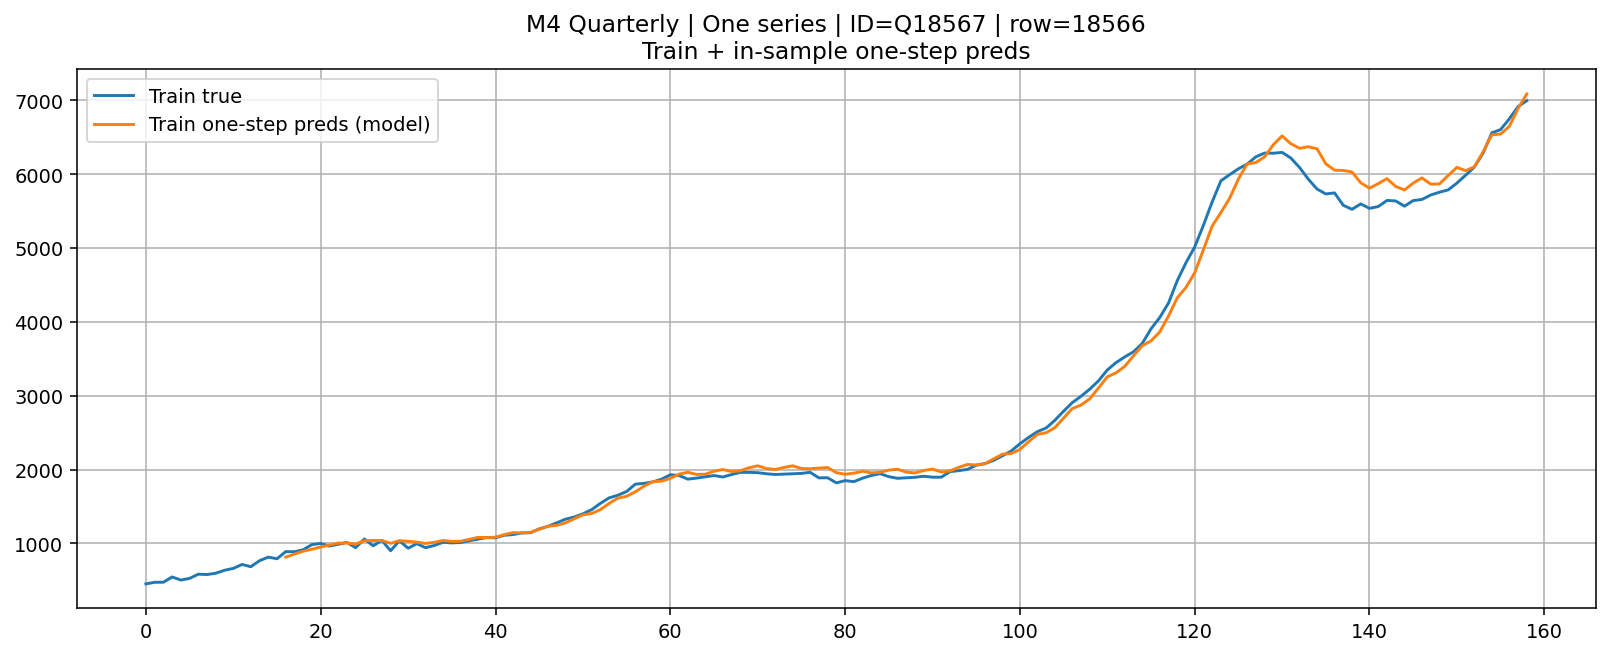

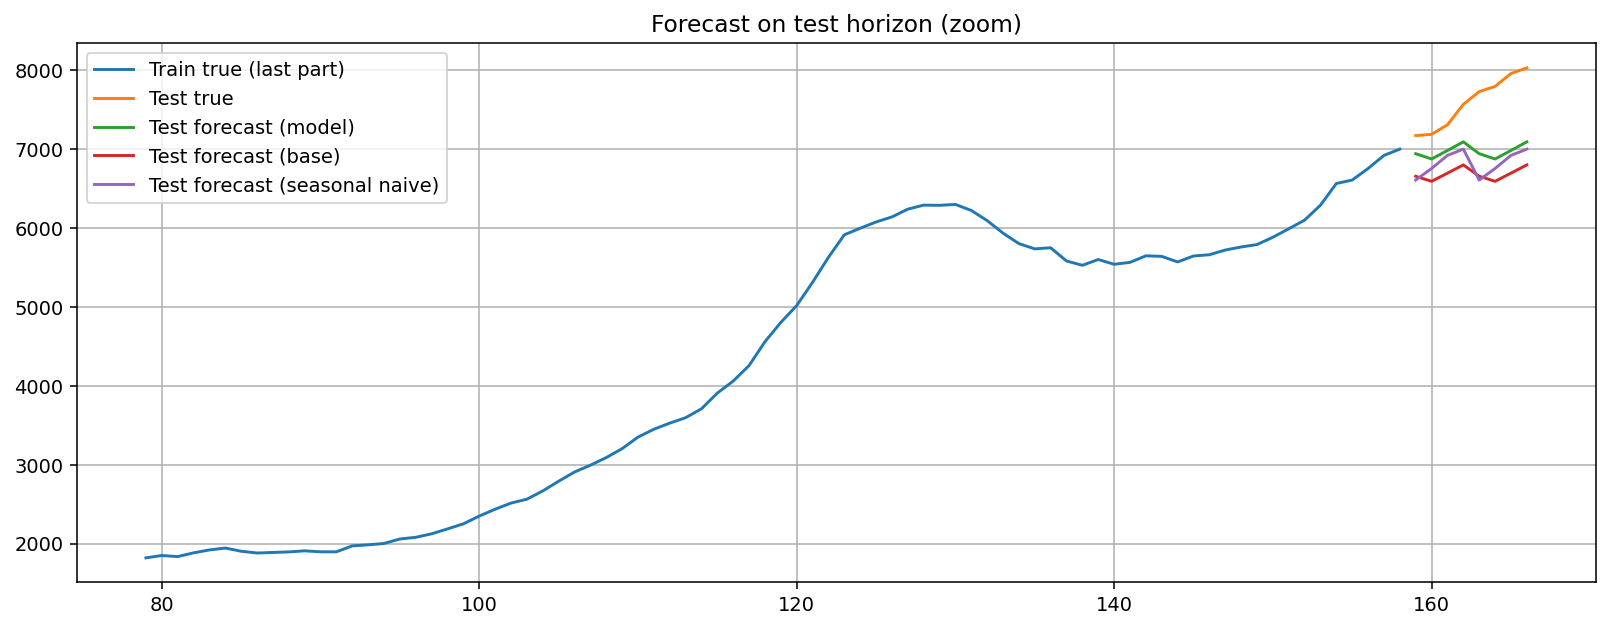

In [18]:
# In-sample one-step predictions (для визуализации на train)
pred_sc = model.predict(scale_Xy(X, y)[0], verbose=0).reshape(-1, 1)
pred_resid = scaler.inverse_transform(pred_sc).reshape(-1).astype(np.float32)

# восстановление train-прогнозов в Close на позициях t = TIME_STEP..end-1
train_pred_close = np.full_like(y_train, np.nan, dtype=np.float32)
for i in range(len(pred_resid)):
    t = i + TIME_STEP
    if mode == "mul":
        train_pred_close[t] = pred_resid[i] * base_train[t]
    else:
        train_pred_close[t] = pred_resid[i] + base_train[t]

# Recursive multi-step forecast on test horizon
window = resid[-TIME_STEP:].copy().astype(np.float32)
test_pred_close = []

for k in range(H):
    x_sc = scaler.transform(window.reshape(-1, 1)).reshape(1, TIME_STEP, 1)
    r_sc = model.predict(x_sc, verbose=0).reshape(-1, 1)
    r_hat = float(scaler.inverse_transform(r_sc)[0, 0])

    # update window
    window = np.concatenate([window[1:], [r_hat]]).astype(np.float32)

    # reconstruct close using BASE FORECAST (no leakage)
    if mode == "mul":
        test_pred_close.append(r_hat * base_forecast[k])
    else:
        test_pred_close.append(r_hat + base_forecast[k])

test_pred_close = np.asarray(test_pred_close, dtype=np.float32)

# Baselines for comparison
hw_like_baseline = base_forecast.astype(np.float32)

# seasonal naive baseline (quarterly): repeat last season from train
seasonal_naive = np.array([y_train[-M + (k % M)] for k in range(H)], dtype=np.float32)

print("H:", H, "test_len:", len(y_test))
print("Model  sMAPE:", smape(y_test, test_pred_close), "MASE:", mase(y_test, test_pred_close, y_train, m=M))
print("Base   sMAPE:", smape(y_test, hw_like_baseline), "MASE:", mase(y_test, hw_like_baseline, y_train, m=M))
print("SNaive sMAPE:", smape(y_test, seasonal_naive),    "MASE:", mase(y_test, seasonal_naive, y_train, m=M))

# --------- PLOTS ----------
# 1) Full train + in-sample predictions
plt.figure(figsize=(14, 5), dpi=140)
plt.title(f"M4 Quarterly | One series | ID={sid_train} | row={row_idx}\nTrain + in-sample one-step preds")
plt.plot(y_train, label="Train true")
plt.plot(train_pred_close, label="Train one-step preds (model)")
plt.legend()
plt.grid(True)
plt.show()

# 2) Zoom near the train/test boundary
zoom = min(80, len(y_train))
x_train = np.arange(len(y_train) - zoom, len(y_train))
x_test = np.arange(len(y_train), len(y_train) + H)

plt.figure(figsize=(14, 5), dpi=140)
plt.title("Forecast on test horizon (zoom)")
plt.plot(x_train, y_train[-zoom:], label="Train true (last part)")
plt.plot(x_test, y_test[:H], label="Test true")
plt.plot(x_test, test_pred_close, label="Test forecast (model)")
plt.plot(x_test, hw_like_baseline, label="Test forecast (base)")
plt.plot(x_test, seasonal_naive, label="Test forecast (seasonal naive)")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
import pandas as pd
import numpy as np

# Load M4 Quarterly data
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Pick a random series from the quarterly dataset
np.random.seed(9)
for random_idx in range(len(train_df)):
    series_id = train_df.iloc[random_idx, 0]
    train_values = train_df.iloc[random_idx, 1:].dropna().values.astype(float)
    test_values  = test_df[test_df.iloc[:, 0] == series_id].iloc[0, 1:].dropna().values.astype(float)
    if len(train_values) > 400:
        break

print(f"Selected series: {series_id}, length {len(train_values)} + {len(test_values)} forecast points")

Selected series: Q3541, length 445 + 8 forecast points


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SeriesDecomp(nn.Module):
    """Moving average series decomposition: trend + seasonal residual."""
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        # Use convolution for moving average
        self.padding = kernel_size // 2

    def forward(self, x: torch.Tensor):
        # x shape: (batch, seq_len, 1)
        if self.padding > 0:
            # Pad with end values at both ends
            left_pad = x[:, :1, :].repeat(1, self.padding, 1)
            right_pad = x[:, -1:, :].repeat(1, self.padding, 1)
            x_padded = torch.cat([left_pad, x, right_pad], dim=1)
        else:
            x_padded = x
        # Moving average via convolution
        if self.kernel_size > 0:
            # 1D convolution over the time axis
            weight = torch.ones((1, 1, self.kernel_size), device=x.device) / self.kernel_size
            trend = F.conv1d(x_padded.transpose(1, 2), weight, padding=0)
            trend = trend.transpose(1, 2)
            # Trim or pad to match original length
            if trend.size(1) > x.size(1):
                trend = trend[:, :x.size(1), :]
            if trend.size(1) < x.size(1):
                # pad last value to match length
                last_val = trend[:, -1:, :]
                trend = torch.cat([trend, last_val.expand(-1, x.size(1)-trend.size(1), -1)], dim=1)
        else:
            trend = x  # no smoothing
        seasonal = x - trend
        return seasonal, trend

def create_training_windows(series: np.ndarray, input_len: int, output_len: int):
    """Create sliding windows of length input_len to predict next output_len points."""
    X, Y = [], []
    total_len = len(series)
    for end_idx in range(input_len, total_len - output_len + 1):
        seq_x = series[end_idx - input_len: end_idx]
        seq_y = series[end_idx: end_idx + output_len]
        X.append(seq_x); Y.append(seq_y)
    return np.array(X), np.array(Y)


In [35]:
if "helformer" in globals() and "x_input" in globals():
    tmp = helformer(x_input)
    print("x_input:", x_input.shape)
    print("helformer(x_input):", tmp.shape)
else:
    print("Run model setup cells first.")


x_input: torch.Size([1, 12, 1])
helformer(x_input): torch.Size([1, 1])


In [40]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Helformer model definition
class HelformerModel(nn.Module):
    def __init__(self, input_dim, model_dim, hidden_dim, n_heads, num_layers, dropout):
        super().__init__()
        self.input_proj = nn.Linear(1, model_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=n_heads, 
                                                  dim_feedforward=hidden_dim, dropout=dropout, batch_first=True)
        self.transformer_enc = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.lstm_dec = nn.LSTM(input_size=model_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        # x: (batch, seq_len, 1)
        x_proj = self.input_proj(x)
        enc_out = self.transformer_enc(x_proj)       # Transformer encoder
        lstm_out, _ = self.lstm_dec(enc_out)         # LSTM decoder on encoded features
        pred = self.fc_out(lstm_out[:, -1, :])       # predict from the last output step
        return pred  # shape: (batch, 1)

# Autoformer model definition
class AutoformerModel(nn.Module):
    def __init__(self, seq_len, label_len, pred_len, d_model=512, n_heads=8, d_ff=2048, moving_avg=25, dropout=0.05):
        super().__init__()
        self.label_len = label_len
        self.pred_len = pred_len
        # Embedding: value embedding and time feature embedding
        self.value_embed = nn.Conv1d(in_channels=1, out_channels=d_model, kernel_size=3, padding=1, padding_mode='circular', bias=False)
        self.position_embed = nn.Linear(4, d_model, bias=False)  # 4 time features (quarter embedding)
        self.dropout = nn.Dropout(dropout)
        # Encoder decomposition + attention layers
        self.decomp = SeriesDecomp(moving_avg)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)  # 2 encoder layers
        # Decoder uses series decomposition within forward pass
        self.projection = nn.Linear(d_model, 1, bias=True)
    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        # x_enc: (batch, seq_len, 1), x_dec: (batch, label_len+pred_len, 1)
        # 1) Decompose input series
        seasonal_init, trend_init = self.decomp(x_enc)
        # Prepare decoder input: last label_len from seasonal_init + zeros for pred_len
        zeros = torch.zeros_like(x_dec[:, -self.pred_len:, :])
        dec_in = torch.cat([seasonal_init[:, -self.label_len:, :], zeros], dim=1)
        # 2) Apply embedding
        # Value embedding (Conv1d) expects shape (batch, C_in, seq_len)
        enc_emb = self.value_embed(x_enc.transpose(1,2)).transpose(1,2)
        dec_emb = self.value_embed(dec_in.transpose(1,2)).transpose(1,2)
        # Add time feature embeddings
        enc_emb = enc_emb + self.position_embed(x_mark_enc)
        dec_emb = dec_emb + self.position_embed(x_mark_dec)
        enc_emb = self.dropout(enc_emb); dec_emb = self.dropout(dec_emb)
        # 3) Encoder forward
        enc_out = self.encoder(enc_emb)  # (batch, seq_len, d_model)
        # 4) Decoder (one-step): use encoder output and trend from input
        seasonal_part = self.encoder(dec_emb)            # reuse encoder layer for decoder seasonal part
        trend_part = torch.cat([trend_init[:, -self.label_len:, :], trend_init[:, -1:, :].repeat(1, self.pred_len, 1)], dim=1)
        # 5) Final output = trend + seasonal projections
        dec_out = self.projection(seasonal_part) + trend_part
        return dec_out[:, -self.pred_len:, :]  # (batch, pred_len, 1)

# FEDformer model definition (Fourier enhanced attention)
import torch.fft as fft
class FEDformerModel(nn.Module):
    def __init__(self, seq_len, label_len, pred_len, d_model=512, n_heads=8, d_ff=2048, moving_avg=25, modes=64, dropout=0.05):
        super().__init__()
        self.label_len = label_len
        self.pred_len = pred_len
        self.modes = modes
        # Embedding
        self.value_embed = nn.Conv1d(in_channels=1, out_channels=d_model, kernel_size=3, padding=1, padding_mode='circular', bias=False)
        self.position_embed = nn.Linear(4, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        # Encoder: one layer of Fourier mixing (frequency attention)
        self.decomp = SeriesDecomp(moving_avg)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        # Use same structure for decoder layers (we will manually apply frequency filtering in forward)
        self.decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.projection = nn.Linear(d_model, 1, bias=True)
    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        # 1) Series decomposition
        seasonal_init, trend_init = self.decomp(x_enc)
        zeros = torch.zeros_like(x_dec[:, -self.pred_len:, :])
        dec_in = torch.cat([seasonal_init[:, -self.label_len:, :], zeros], dim=1)
        # 2) Embedding
        enc_emb = self.value_embed(x_enc.transpose(1,2)).transpose(1,2) + self.position_embed(x_mark_enc)
        dec_emb = self.value_embed(dec_in.transpose(1,2)).transpose(1,2) + self.position_embed(x_mark_dec)
        enc_emb = self.dropout(enc_emb); dec_emb = self.dropout(dec_emb)
        # 3) Encoder forward (standard attention)
        enc_out = self.encoder(enc_emb)
        # 4) Decoder with frequency enhanced cross-attention
        # Apply Fourier transform on decoder input and encoder output
        B, Ld, D = dec_emb.shape
        _, Le, _ = enc_out.shape
        # If needed, pad encoder output length to match decoder length
        enc_out_resized = enc_out
        if Le != Ld:
            enc_out_resized = F.interpolate(enc_out.transpose(1,2), size=Ld, mode='linear', align_corners=False).transpose(1,2)
        # FFT on decoder and encoder sequences
        dec_freq = fft.rfft(dec_emb, dim=1)
        enc_freq = fft.rfft(enc_out_resized, dim=1)
        # Select top-k low-frequency modes
        freq_len = dec_freq.size(1)
        k = min(self.modes, freq_len)
        # (for simplicity, take first k frequencies)
        dec_freq[:, k:, :] *= 0
        enc_freq[:, k:, :] *= 0
        # Inverse FFT to get filtered sequences
        dec_ifft = fft.irfft(dec_freq, n=Ld, dim=1)
        enc_ifft = fft.irfft(enc_freq, n=Ld, dim=1)
        # Single decoder layer using filtered sequences as query (dec) and key/value (enc)
        dec_out = self.decoder_layer(dec_ifft, enc_ifft)
        # 5) Output projection plus trend
        dec_out = self.projection(dec_out) + torch.cat([trend_init[:, -self.label_len:, :], trend_init[:, -1:, :].repeat(1, self.pred_len, 1)], dim=1)
        return dec_out[:, -self.pred_len:, :]


In [41]:
import torch.optim as optim

# Parameters
input_len = 12   # input sequence length for training (e.g., 12 quarters)
output_len = len(test_values)  # predict the next quarters equal to test length
batch_size = 1

# Prepare training windows
X_train, Y_train = create_training_windows(train_values, input_len, output_len)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(device)  # shape (n_windows, input_len, 1)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(-1).to(device)  # shape (n_windows, output_len, 1)

# Prepare time feature embeddings (quarter-of-year as one-hot or scaled features)
def make_time_features(length, start_q=1):
    # Generate time features [quarter_of_year, month, day, weekday] scaled 0-1
    # Here quarter -> {0,1,2,3}, month -> actual month (Mar, Jun, Sep, Dec), day and weekday fixed for simplicity
    quarters = [(start_q + i) % 4 for i in range(length)]
    months = [3 if q==1 else 6 if q==2 else 9 if q==3 else 12 for q in quarters]  # approximate month of quarter end
    # Use constant day=30 and derive weekday (not too important for quarter data)
    days = [30]*length
    weekdays = [0]*length
    # Scale features to [0,1]
    q_feat = np.array(quarters)/3.0
    m_feat = (np.array(months)-1)/11.0
    d_feat = (np.array(days)-1)/30.0
    w_feat = np.array(weekdays)/6.0
    return torch.tensor(np.stack([m_feat, d_feat, w_feat, q_feat], axis=1), dtype=torch.float32)

# Instantiate models
helformer = HelformerModel(input_dim=1, model_dim=16, hidden_dim=32, n_heads=2, num_layers=2, dropout=0.2).to(device)
autoformer = AutoformerModel(seq_len=input_len, label_len=output_len, pred_len=output_len, d_model=16, n_heads=2, d_ff=32, moving_avg=5).to(device)
fedformer = FEDformerModel(seq_len=input_len, label_len=output_len, pred_len=output_len, d_model=16, n_heads=2, d_ff=32, moving_avg=5, modes=8).to(device)

models = {"Helformer": helformer, "Autoformer": autoformer, "FEDformer": fedformer}
optimizers = {name: optim.Adam(model.parameters(), lr=1e-3) for name, model in models.items()}
criterion = nn.MSELoss()

# Training loop (50 epochs)
epochs = 50
for epoch in range(epochs):
    # Time features for input and (label+pred) for dec
    # Here we generate features assuming sequential quarters
    x_mark_enc = make_time_features(input_len).unsqueeze(0).to(device)            # (1, input_len, 4)
    # label_len + pred_len time features for decoder input
    dec_in_len = output_len + output_len  # label_len = output_len in our window slicing
    x_mark_dec = make_time_features(dec_in_len, start_q=(1+input_len)%4).unsqueeze(0).to(device)
    x_dec = torch.cat([
        X_train_t[:, -output_len:, :],
        torch.zeros(X_train_t.size(0), output_len, 1, device=device)
    ], dim=1)

    for name, model in models.items():
        model.train()
        optimizer = optimizers[name]
        optimizer.zero_grad()
        # Forward pass
        if name == "Helformer":
            preds = model(X_train_t)        # Helformer outputs only final step
            preds = preds.unsqueeze(1)      # make shape (batch, 1, 1)
        else:
            preds = model(X_train_t, x_mark_enc, x_dec, x_mark_dec)
        loss = criterion(preds, Y_train_t)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        hf_loss = criterion(helformer(X_train_t).unsqueeze(1), Y_train_t).item()
        auto_loss = criterion(autoformer(X_train_t, x_mark_enc, x_dec, x_mark_dec), Y_train_t).item()
        fed_loss = criterion(fedformer(X_train_t, x_mark_enc, x_dec, x_mark_dec), Y_train_t).item()
        print(f"Epoch {epoch} loss - Helformer: {hf_loss:.4f}, Autoformer: {auto_loss:.4f}, FEDformer: {fed_loss:.4f}")


TypeError: TransformerEncoderLayer.forward() got multiple values for argument 'src_mask'

In [42]:
# Switch models to evaluation mode
for model in models.values():
    model.eval()

# Prepare input for forecasting = last `input_len` points from training
x_input = torch.tensor(train_values[-input_len:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
x_mark_enc = make_time_features(input_len, start_q=((len(train_values)%4) or 4)).unsqueeze(0).to(device)
x_mark_dec = make_time_features(output_len + output_len, start_q=((len(train_values)%4) or 4) ).unsqueeze(0).to(device)

forecast_results = {}

# Helformer forecast
with torch.no_grad():
    hf_pred = helformer(x_input)  # shape (1, 1)
    hf_pred = hf_pred.cpu().numpy().flatten()
    # For multiple steps, we iterate feeding back prediction (since Helformer outputs one step at a time)
    # Here output_len == test length, we can feed sequentially
    hf_forecast = []
    last_input = x_input.clone()
    for _ in range(output_len):
        with torch.no_grad():
            step_pred = helformer(last_input)  # (1,1)
        hf_forecast.append(step_pred.item())
        # append this pred to last_input and remove oldest
        new_seq = torch.cat([last_input[:, 1:, :], step_pred.unsqueeze(-1)], dim=1)
        last_input = new_seq
    forecast_results["Helformer"] = np.array(hf_forecast)

    # Autoformer forecast
    auto_pred_seq = autoformer(x_input, x_mark_enc, torch.cat([x_input[:, -output_len:, :], torch.zeros(1, output_len, 1).to(device)], dim=1), x_mark_dec)
    forecast_results["Autoformer"] = auto_pred_seq.cpu().numpy().flatten()

    # FEDformer forecast
    fed_pred_seq = fedformer(x_input, x_mark_enc, torch.cat([x_input[:, -output_len:, :], torch.zeros(1, output_len, 1).to(device)], dim=1), x_mark_dec)
    forecast_results["FEDformer"] = fed_pred_seq.cpu().numpy().flatten()

# ARIMA forecast (using statsmodels)
import statsmodels.api as sm
arima_model = sm.tsa.ARIMA(train_values, order=(1,1,1), seasonal_order=(0,0,0,0))
arima_res = arima_model.fit()
arima_forecast = arima_res.forecast(steps=output_len)
forecast_results["ARIMA"] = np.array(arima_forecast)

# ETS forecast (Holt-Winters exponential smoothing)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
ets_model = ExponentialSmoothing(train_values, trend="add", seasonal="add", seasonal_periods=4).fit()
ets_forecast = ets_model.forecast(output_len)
forecast_results["ETS"] = np.array(ets_forecast)

# Prophet forecast
from prophet import Prophet
# Prepare DataFrame for Prophet
df = pd.DataFrame({
    "ds": pd.period_range(start='2000Q1', periods=len(train_values), freq='Q').to_timestamp(), 
    "y": train_values
})
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(df)
future = prophet_model.make_future_dataframe(periods=output_len, freq='Q')
forecast_df = prophet_model.predict(future)
prophet_forecast = forecast_df['yhat'].iloc[-output_len:].values
forecast_results["Prophet"] = prophet_forecast

# Print forecast arrays
for name, preds in forecast_results.items():
    print(f"{name} forecast: {preds}")


RuntimeError: Tensors must have same number of dimensions: got 3 and 4

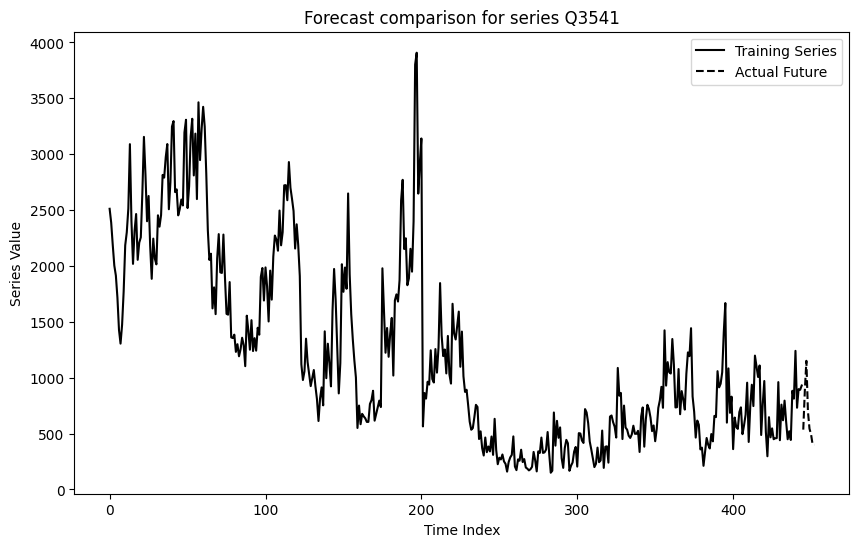

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# Plot training history
plt.plot(range(len(train_values)), train_values, label="Training Series", color="black")
# Plot actual future values
future_index = range(len(train_values), len(train_values) + len(test_values))
plt.plot(future_index, test_values, label="Actual Future", color="black", linestyle="--")
# Plot each model's forecast
for name, preds in forecast_results.items():
    plt.plot(future_index, preds, label=name)
plt.xlabel("Time Index")
plt.ylabel("Series Value")
plt.title(f"Forecast comparison for series {series_id}")
plt.legend()
plt.show()
